# Run run_paper_nee

In [1]:
# Env: sc2_v0
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy import stats
import xskillscore as xs
import calendar
import os

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
site_byl = 'byl'
site_longname_byl = 'Bylot Island, Canadian high Arctic'
y_start_byl = 2013
y_end_byl = 2019

# labels = ['peat_30min_ext', 'peat']
labels = [
    'peat_DEF', 
    # 'Ref', #no peat
    # 'peat_BUG_CORRECT',
    # 'peat_BUG_CORRECT_TSNBT_OP1',
    # 'peat_BUG_CORRECT_TSNBT_OP1_EZERO',
    # 'peat_PHYS_ALL_SUBLI_CORRECT',
   # 'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1',
   # 'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne', # Best without TVC (COMPACT_2.5)
   'peat_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne', # best with TVC
]

root_path = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowArctic/'+site_byl+'/'
paths = [root_path+'run_'+label for label in labels]

# ds_yr_list = [xr.open_mfdataset(path+'/*_annually.nc').squeeze().load() for path in paths]
# ds_mo_list = [xr.open_mfdataset(path+'/*_monthly.nc').squeeze().load() for path in paths]
ds_d_list_byl = [xr.open_mfdataset(path+'/*_daily.nc').squeeze().load() for path in paths]
# ds_hh_list = [xr.open_mfdataset(path+'/*_halfhourly.nc').squeeze().load() for path in paths]

In [4]:
path = "/home/mickael-lalande/eccc/classic-develop/inputFiles/SnowArctic/"+site_byl
rsfile = xr.open_dataset(path+'/rsfile_spinup-final_Ref.nc')

In [5]:
def assign_center_depth(ds, rsfile):
    layer_c = []
    for i in range(len(rsfile.DELZ)):
        if i == 0:
            layer_c.append(rsfile.DELZ.cumsum().values[i]/2)
        else:
            layer_c.append(rsfile.DELZ.cumsum().values[i-1] + rsfile.DELZ.values[i]/2)
    with xr.set_options(keep_attrs=True):
        ds = ds.assign_coords(layer=ds.layer*0+layer_c)
    return ds

In [6]:
for i in range(len(labels)):
    ds_d_list_byl[i] = assign_center_depth(ds_d_list_byl[i], rsfile)

In [7]:
site_umt = 'umt'
site_longname_umt = 'Umiujaq TUNDRA, northeastern Canada'
y_start_umt = 2012
y_end_umt = 2021

labels = [
    'DEF_correct_SH',
    # 'Ref', #no peat
    # 'BUG_CORRECT',
    # 'BUG_CORRECT_TSNBT_OP1',
    # 'BUG_CORRECT_TSNBT_OP1_EZERO',
    # 'PHYS_ALL_SUBLI_CORRECT',
    # 'PHYS_ALL_SUBLI_v2',
    # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
    # 'PHYS_ALL_SUBLI_v2_COMPAC_v1',
    # 'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne', # Best without TVC (COMPACT_2.5)
    'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH', # best with TVC
]

root_path = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowArctic/'+site_umt+'/'
paths = [root_path+'run_'+label for label in labels]

# ds_yr_list = [xr.open_mfdataset(path+'/*_annually.nc').squeeze().load() for path in paths]
# ds_mo_list = [xr.open_mfdataset(path+'/*_monthly.nc').squeeze().load() for path in paths]
ds_d_list_umt = [xr.open_mfdataset(path+'/*_daily.nc').squeeze().load() for path in paths]
# ds_hh_list = [xr.open_mfdataset(path+'/*_halfhourly.nc').squeeze().load() for path in paths]

In [8]:
path = "/home/mickael-lalande/eccc/classic-develop/inputFiles/SnowArctic/"+site_umt
rsfile = xr.open_dataset(path+'/rsfile_spinup-final_Ref.nc')

In [9]:
for i in range(len(labels)):
    ds_d_list_umt[i] = assign_center_depth(ds_d_list_umt[i], rsfile)

In [10]:
site_tvc = 'tvc'
site_longname_tvc = 'Trail Valley Creek, northwestern Canada'
y_start_tvc = 2013
y_end_tvc = 2019

labels = [
    '1peat_2xSnowf_DEF_correct_SH',
    # 'Ref_30min_ext', #no peat
    # 'BUG_CORRECT',
    # 'BUG_CORRECT_TSNBT_OP1',
    # '1peat_2xSnowf_BUG_CORRECT_TSNBT_OP1_EZERO',
    # 'PHYS_ALL_SUBLI_CORRECT',
    # '1peat_2xSnowf_PHYS_ALL_SUBLI_v2',
    # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
    # '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1',
    # '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne', # Best without TVC (COMPACT_2.5)
    '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH', # best with TVC
    
]

root_path = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowArctic/'+site_tvc+'/'
paths = [root_path+'run_'+label for label in labels]

# ds_yr_list = [xr.open_mfdataset(path+'/*_annually.nc').squeeze().load() for path in paths]
# ds_mo_list = [xr.open_mfdataset(path+'/*_monthly.nc').squeeze().load() for path in paths]
ds_d_list_tvc = [xr.open_mfdataset(path+'/*_daily.nc').squeeze().load() for path in paths]
# ds_hh_list = [xr.open_mfdataset(path+'/*_halfhourly.nc').squeeze().load() for path in paths]

In [11]:
path = "/home/mickael-lalande/eccc/classic-develop/inputFiles/SnowArctic/"+site_tvc
rsfile = xr.open_dataset(path+'/rsfile_spinup-final_Ref_30min_ext.nc')

In [12]:
for i in range(len(labels)):
    ds_d_list_tvc[i] = assign_center_depth(ds_d_list_tvc[i], rsfile)

## Convert noleap year cftime to datetime

In [13]:
ds_d_list_tvc[i].time

<xarray.DataArray 'time' (time: 2555)>
array([cftime.DatetimeNoLeap(2013, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2013, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2013, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2019, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2019, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2019, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 2013-01-01 00:00:00 ... 2019-12-31 00:00:00
Attributes:
    long_name:  time

In [14]:
import cftime
for i in range(len(labels)):
    if isinstance(ds_d_list_tvc[i]['time'].values[0], cftime.DatetimeNoLeap):
        ds_d_list_tvc[i]['time'] = pd.to_datetime(ds_d_list_tvc[i].indexes['time'].to_datetimeindex())

## Compare with obs

In [15]:
path_obs = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Bylot'

ds_h_obs = xr.open_dataset(path_obs+'/obs_insitu_'+site_byl+'_'+str(y_start_byl)+'_'+str(y_end_byl)+'.nc').load()
ds_d_obs_byl = ds_h_obs.resample(time='D').mean().load()

ds_d_obs_byl

<xarray.Dataset>
Dimensions:         (time: 2176, sdepth: 5, sheight: 10)
Coordinates:
  * sdepth          (sdepth) float64 0.02 0.05 0.1 0.15 0.21
  * sheight         (sheight) float64 0.0 0.02 0.05 0.07 ... 0.25 0.27 0.35 0.37
  * time            (time) datetime64[ns] 2013-07-11 2013-07-12 ... 2019-06-25
Data variables:
    snd_auto        (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    albs            (time) float64 0.1815 0.1357 0.1493 ... 0.1393 0.1625 0.1964
    flag_albs_ERA5  (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    ts              (time) float64 11.03 5.161 6.706 7.563 ... 5.245 4.045 4.336
    mrsll           (time, sdepth) float64 0.1981 0.4431 ... 0.08873 0.066
    tsl             (time, sdepth) float64 6.497 3.928 1.357 ... 0.79 -0.3
    tsnl            (time, sheight) float64 nan nan nan nan ... nan nan nan nan
Attributes:
    reference:    Domine, F., Lackner, G., Sarrazin, D., Poirier, M., & Belke...
    description:  Converted to netCDF (SnowMIP kind of format) from original ...

In [16]:
path_obs = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'

ds_h_obs = xr.open_dataset(path_obs+'/obs_insitu_'+site_umt+'_'+str(y_start_umt)+'_'+str(y_end_umt)+'.nc').load()

ds_d_obs_umt = ds_h_obs.resample(time='D').mean().load()
ds_d_obs_umt

<xarray.Dataset>
Dimensions:   (veg: 2, sdepth: 4, time: 3309)
Coordinates:
  * veg       (veg) object 'lichen' 'lowshrub'
  * sdepth    (sdepth) float64 0.15 0.25 0.35 0.45
  * time      (time) datetime64[ns] 2012-09-28 2012-09-29 ... 2021-10-19
Data variables:
    snd_auto  (time) float64 0.0 0.01196 0.02252 ... 0.03703 0.05901 0.0582
    mrsll     (time, veg, sdepth) float64 nan nan nan nan ... nan nan nan nan
    tsl       (time, veg, sdepth) float64 nan nan nan nan ... nan nan nan nan
    albs      (time) float64 0.08978 0.0732 0.1486 ... 0.1283 0.119 0.1677
Attributes:
    event:          Umiujaq_2012-2021_Tundra
    link:           https://doi.pangaea.de/10.1594/PANGAEA.964743
    downloaded:     27/02/2024 by Mickaël Lalande
    original_file:  Domine-etal_2024/datasets/Umiujaq_snow_height.tab, Umiuja...

In [17]:
path_obs = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/TVC/TVCSnowCLM/TVCMetData'
ds_h_obs = xr.open_dataset(path_obs+'/obs_insitu_tvc_2017_2019.nc')
ds_d_obs_tvc = ds_h_obs.resample(time='D').mean().load()
ds_d_obs_tvc['snd_auto'] = ds_d_obs_tvc.snd_auto/100
ds_d_obs_tvc = ds_d_obs_tvc.rename({'albedo': 'albs', 'swc': 'mrsll'})
ds_d_obs_tvc

<xarray.Dataset>
Dimensions:           (time: 668, sdepth: 4)
Coordinates:
  * sdepth            (sdepth) float64 0.02 0.05 0.1 0.2
  * time              (time) datetime64[ns] 2017-09-01 2017-09-02 ... 2019-06-30
Data variables: (12/14)
    snd_auto          (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    tsl               (time, sdepth) float64 5.021 3.834 3.575 ... 5.732 4.72
    mrsll             (time, sdepth) float64 0.232 0.1819 0.3397 ... 0.287 0.433
    SoilHEatFlux_org  (time) float64 6.104 11.39 9.86 1.357 ... nan nan nan nan
    SoilHEatFlux_min  (time) float64 5.848 12.86 11.75 7.613 ... nan nan nan nan
    NEE_filt          (time) float64 -0.8253 0.1094 0.406 ... -2.071 -0.0614
    ...                ...
    NEE_filled        (time) float64 0.152 0.6982 0.6329 ... -1.871 -0.0614
    LE_filled         (time) float64 22.29 16.89 21.12 ... 32.07 27.5 -1.015
    H_filled          (time) float64 17.54 12.97 17.06 ... 94.89 78.96 -12.94
    CH4_filt          (time) float64 0.001279 0.001616 0.002003 ... nan nan nan
    CH4_filled        (time) float64 0.001136 0.001072 ... 0.001958 0.0002559
    albs              (time) float64 0.1721 0.1551 0.209 ... 0.2437 0.225 0.331
Attributes:
    location:    Trail Valley Creak
    ref:         https://doi.org/10.5194/tc-16-4201-2022
    soil_ref:    https://doi.pangaea.de/10.1594/PANGAEA.962726
    downloaded:  13/10/2024 by Mickaël Lalande
    merge:       TVCSnowCLM/TVCMetData/MSC_Snowdepth.csv and TVC_CLASSIC_2013...

In [18]:
path_obs = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
df_turb = pd.read_csv(path_obs+'/Umiujaq_turbulent_CO2_flux.tab', skiprows=29, delimiter='\t', parse_dates=['Date/Time'], index_col=['Date/Time'])
df_turb

,Qh [W/m**2],QF Qh,Qe [W/m**2],QF Qe,CO2 flux [µmol/m**2/s],QF CO2 flux
Date/Time,,,,,,
2017-06-10 15:00:00,76.441,1,-23.175,1,-7.882,0
2017-06-10 15:30:00,83.783,1,82.376,1,0.983,0
2017-06-10 16:00:00,76.397,1,46.145,1,-3.274,0
2017-06-10 16:30:00,77.477,1,46.932,1,-9.641,0
2017-06-10 17:00:00,78.918,1,-28.091,1,-1.614,1
...,...,...,...,...,...,...
2020-04-30 17:00:00,3.892,0,10.298,0,-0.067,0
2020-04-30 17:30:00,-1.309,0,3.916,0,-0.105,0
2020-04-30 18:00:00,-4.647,0,1.461,0,-0.081,0


In [19]:
ds_turb = df_turb.to_xarray()
ds_turb = ds_turb.rename({'Date/Time': 'time', 'Qh [W/m**2]': 'hfss', 'Qe [W/m**2]': 'hfls', 'CO2 flux [µmol/m**2/s]': 'nee'})
ds_turb['hfss'].attrs = {'units': 'W/m$^2$'}
ds_turb['hfls'].attrs = {'units': 'W/m$^2$'}
ds_turb['nee'].attrs = {'units': 'µmol m$^{-2}$ s$^{-1}$'}
ds_turb

<xarray.Dataset>
Dimensions:      (time: 50649)
Coordinates:
  * time         (time) datetime64[ns] 2017-06-10T15:00:00 ... 2020-04-30T19:...
Data variables:
    hfss         (time) float64 76.44 83.78 76.4 77.48 ... -4.647 -7.894 -10.42
    QF Qh        (time) int64 1 1 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0 0
    hfls         (time) float64 -23.18 82.38 46.15 46.93 ... 1.461 -0.158 -0.081
    QF Qe        (time) int64 1 1 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0 0
    nee          (time) float64 -7.882 0.983 -3.274 ... -0.081 -0.022 0.137
    QF CO2 flux  (time) int64 0 0 0 0 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0 0

In [20]:
ds_d_turb = ds_turb.resample(time='D').mean().load()
ds_d_turb

<xarray.Dataset>
Dimensions:      (time: 1056)
Coordinates:
  * time         (time) datetime64[ns] 2017-06-10 2017-06-11 ... 2020-04-30
Data variables:
    hfss         (time) float64 25.74 52.04 8.584 31.78 ... -21.79 -4.363 -3.511
    QF Qh        (time) float64 1.0 0.04167 0.0 0.375 0.0 ... 0.2083 0.0 0.0 0.0
    hfls         (time) float64 -19.92 35.8 14.05 23.55 ... 6.472 5.114 1.974
    QF Qe        (time) float64 1.0 0.2708 0.3542 0.7708 ... 0.0 0.0 0.0 0.0
    nee          (time) float64 -0.6061 -0.8551 -0.6676 ... -0.1087 -0.01772
    QF CO2 flux  (time) float64 0.7778 0.1042 0.3333 0.7708 ... 0.0 0.0 0.0 0.0

In [21]:
y_start_byl

2013

In [22]:
# label_exps = ['DEF', 'PHYS', '+ SUBLI', '+ COMPAC', '+ CL11', 'ALL_TVC']
# label_exps = ['DEF', 'DEF (no peat)', 'ALL_TVC']
label_exps = ['DEF', 'ALL_TVC']


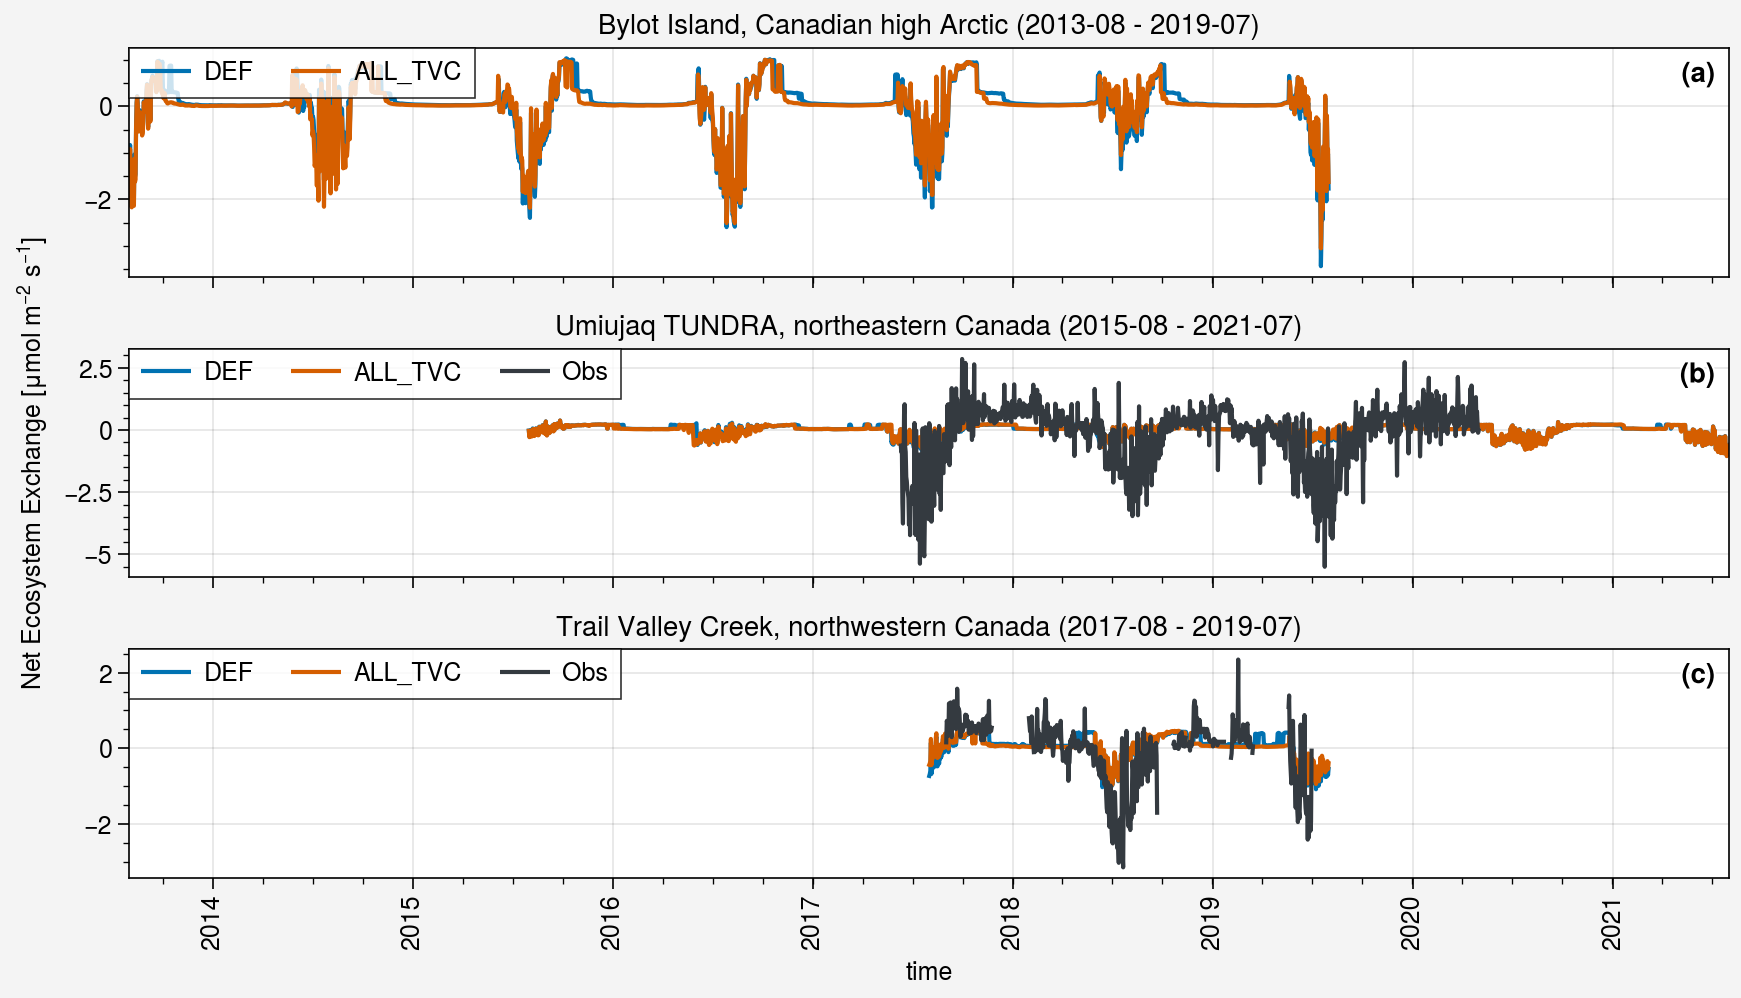

In [23]:
%matplotlib inline
color_obs = 'gray8'

fig, axs = pplt.subplots(ncols=1, nrows=3, refaspect=7, refwidth=8)


###########
### byl ###
###########

period=slice(str(y_start_byl)+'-08',str(y_end_byl)+'-07')

# Simus
for ds_d, label, label_exp in zip(ds_d_list_byl, labels, label_exps):
    axs[0].plot(-ds_d.nep.sel(time=period)*86400e3, label=label_exp)
    
# Obs
# axs[0].plot(ds_d_obs_byl.mrsll.sel(time=period), color=color_obs, label='Obs')
axs[0].format(title=site_longname_byl + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [$\mu$mol m$^{-2}$ s$^{-1}$]')



###########
### umt ###
###########

period=slice('2015-08',str(y_end_umt)+'-07')

sdepth = 0.15
sdepth_label = str(int(sdepth*100))
# Simus
for ds_d, label, label_exp in zip(ds_d_list_umt, labels, label_exps):
    axs[1].plot(-ds_d.nep.sel(time=period)*86400e3, label=label_exp)
    
# Obs
axs[1].plot(ds_d_turb.nee.sel(time=period)*1.038, color=color_obs, label='Obs')
axs[1].format(title=site_longname_umt + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [$\mu$mol m$^{-2}$ s$^{-1}$]')



###########
### tvc ###
###########

period=slice('2017-08',str(y_end_tvc)+'-07')

sdepth = 0.05
sdepth_label = str(int(sdepth*100))
# Simus
for ds_d, label, label_exp in zip(ds_d_list_tvc, labels, label_exps):
    axs[2].plot(-ds_d.nep.sel(time=period)*86400e3, label=label_exp)
    
# Obs
axs[2].plot(ds_d_obs_tvc.NEE_filled.sel(time=period)*1.038, color=color_obs, label='Obs')
axs[2].format(title=site_longname_tvc + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [$\mu$mol m$^{-2}$ s$^{-1}$]')

for ax in axs:
    # ax.format(ylim=(0,0.9))
    ax.legend(loc='ul')

fig.format(abc='(a)', abcloc='ur')
# fig.suptitle(site_longname_byl)

# fig.save('arctic_vwc.png')
# fig.save('arctic_vwc.jpg')
# fig.save('arctic_vwc.pdf')

In [24]:
ds_d.nep

<xarray.DataArray 'nep' (time: 2555)>
array([-5.08596058e-10, -5.48804541e-10, -5.86608626e-10, ...,
       -1.92503909e-10, -2.09399853e-10, -2.19396835e-10])
Coordinates:
  * time     (time) datetime64[ns] 2013-01-01 2013-01-02 ... 2019-12-31
Attributes:
    long_name:   Natural flux of CO2 (expressed as a mass flux of carbon) fro...
    units:       kg m$^{-2}$ s$^{-1}$
    nameInCode:  nep_d_g

## Conversions

µmol CO₂ to gC

Molecular weight of CO₂

Carbon (C) = 12.01 g/mol
Oxygen (O₂) = 2 × 16.00 g/mol = 32.00 g/mol
Total CO₂ molar mass = 44.01 g/mol


1. Each molecule of CO₂ contains one carbon atom, so:
$$
1 \mu mol CO_2 = 1 \mu mol C = 10^{-6} mol C = 12.01 \times 10^{-6} gC
$$

2. Convert per second to per day:
$$
1 \mu mol CO_2 m^{-2} s^{-1} = 12.01 \times  10^{-6} \times 86400 gC m^{-2} d^{-1} = 1.038 gC m^{-2} d^{-1}
$$

In [25]:
1e-6

1e-06

In [26]:
10**(-6)

1e-06

In [27]:
12.01*86400*1e-6

1.037664

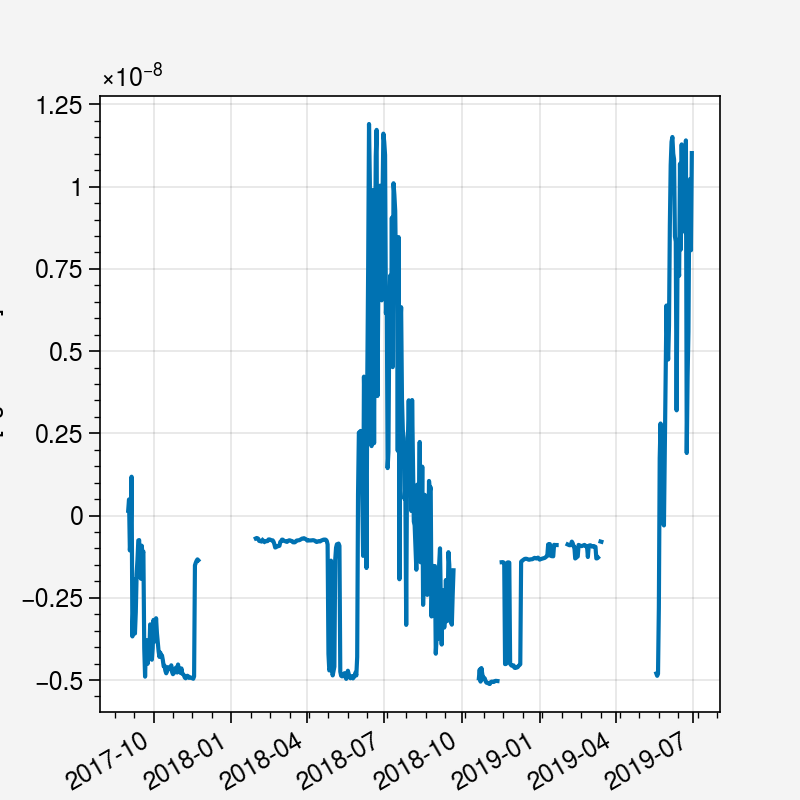

In [28]:
ds_d_list_tvc[0].nep.sel(time=period).where(~ds_d_obs_tvc.NEE_filled.sel(time=period).isnull()).plot()

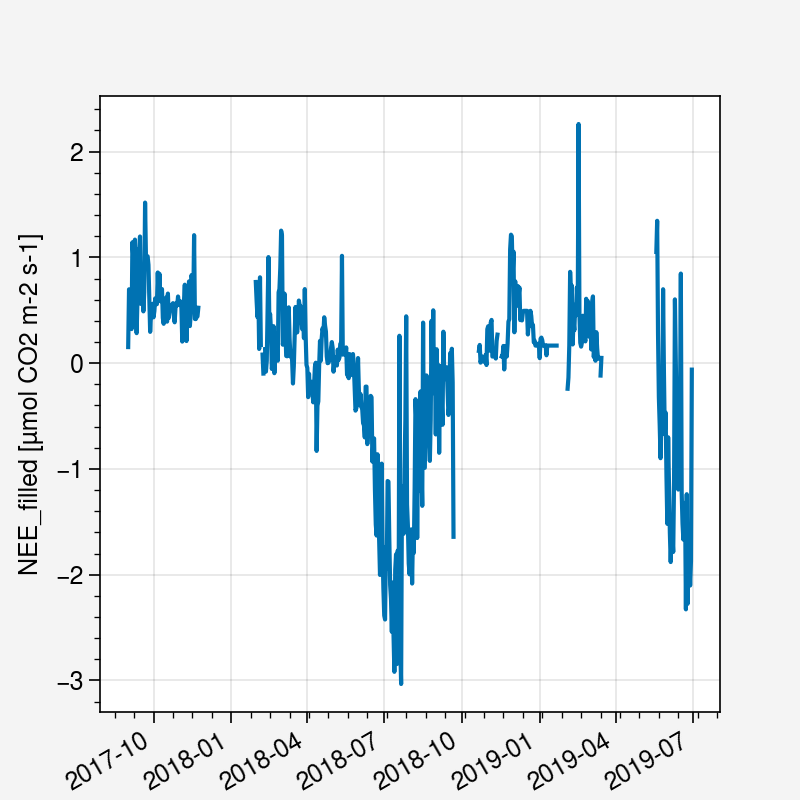

In [29]:
ds_d_obs_tvc.NEE_filled.sel(time=period).plot()

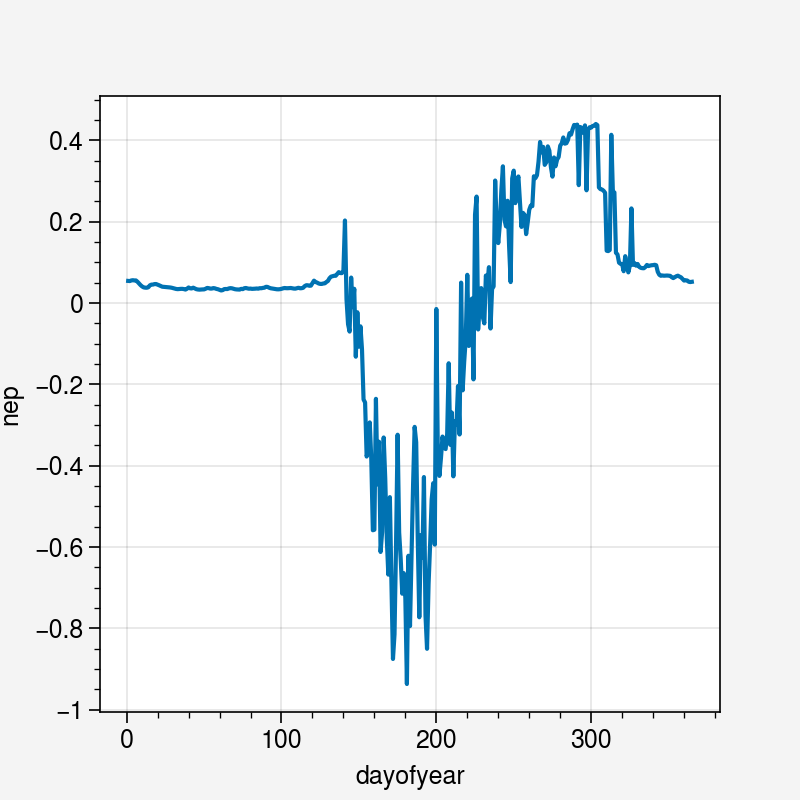

In [30]:
(-ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3).plot()

In [31]:
a = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3

In [32]:
a.sum()

<xarray.DataArray 'nep' ()>
array(3.68902037)

In [33]:
a.where(a > 0).sum()

<xarray.DataArray 'nep' ()>
array(35.85942131)

In [34]:
a.where(a < 0).sum()

<xarray.DataArray 'nep' ()>
array(-32.17040094)

In [35]:
(-ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3).sum()

<xarray.DataArray 'nep' ()>
array(3.68902037)

In [36]:
(-ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3).sum()

<xarray.DataArray 'nep' ()>
array(3.68902037)

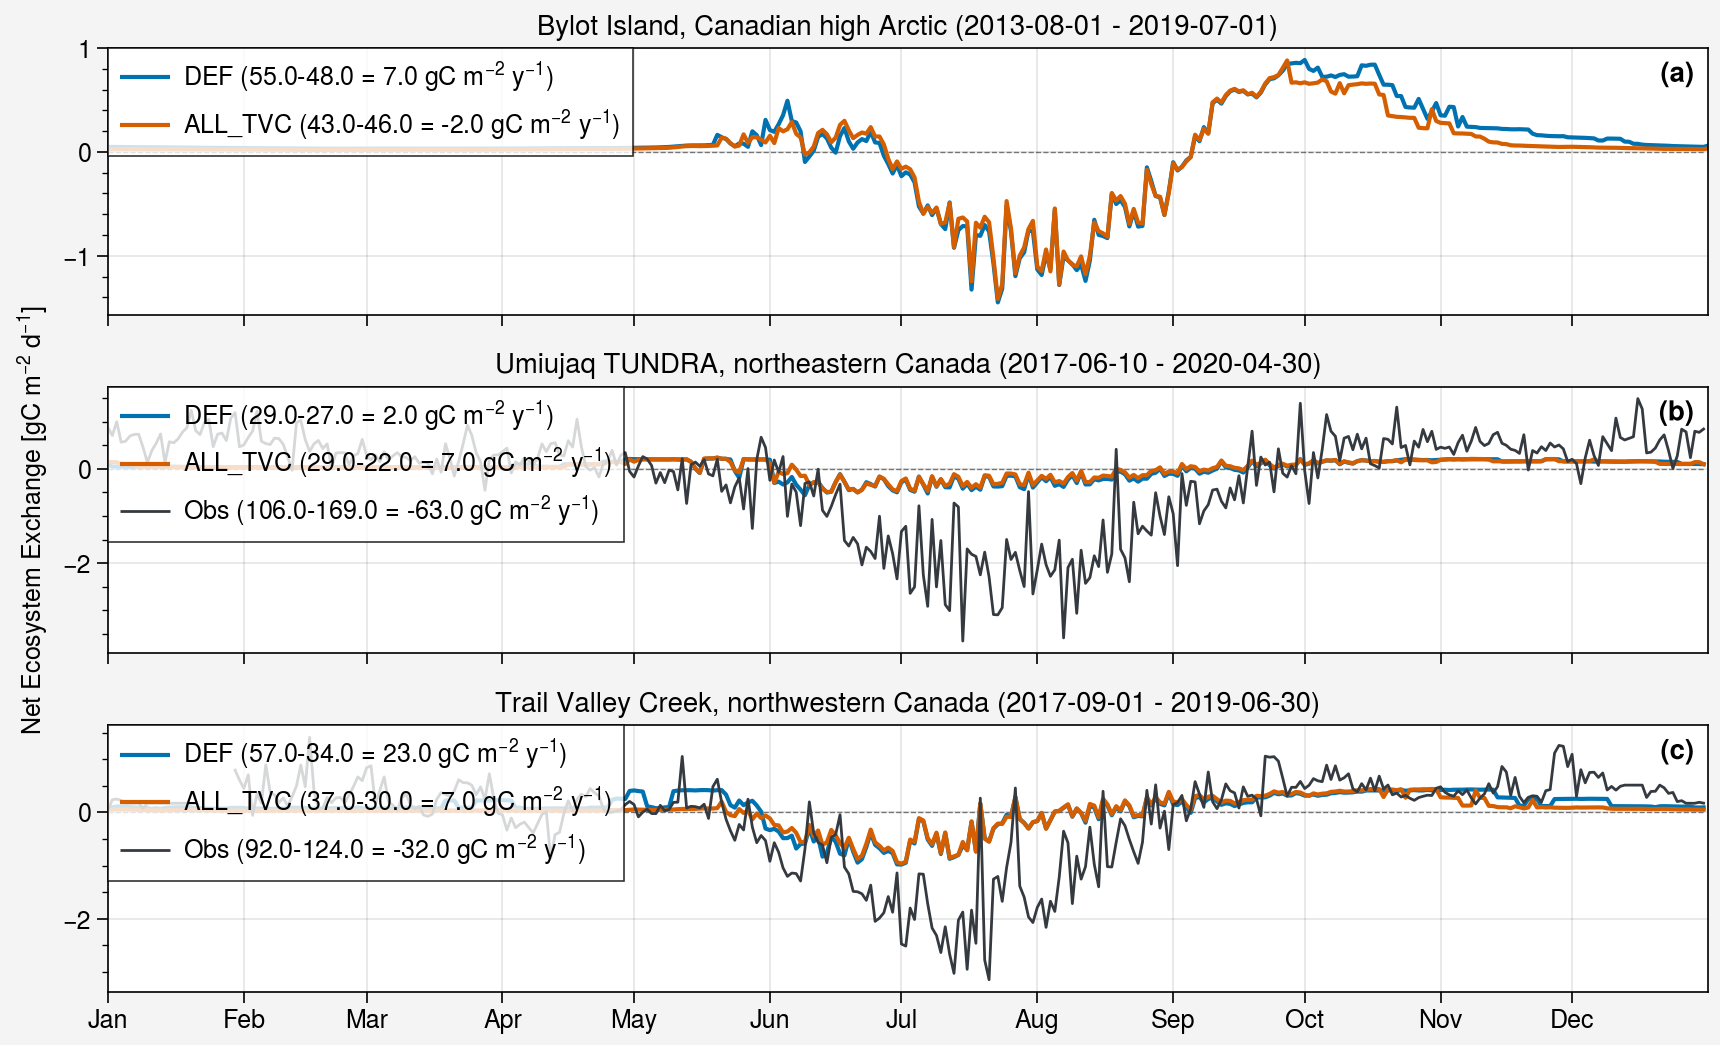

In [ ]:
%matplotlib inline
color_obs = 'gray8'

fig, axs = pplt.subplots(ncols=1, nrows=3, refaspect=6, refwidth=8)

# Month start DOY (non-leap year)
xticks = [
    1,    # Jan
    32,   # Feb
    60,   # Mar
    91,   # Apr
    121,  # May
    152,  # Jun
    182,  # Jul
    213,  # Aug
    244,  # Sep
    274,  # Oct
    305,  # Nov
    335   # Dec
]

# 3-letter month labels
xlabels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


###########
### byl ###
###########

period=slice(str(y_start_byl)+'-08-01',str(y_end_byl)+'-07-01')

# Simus
for ds_d, label, label_exp in zip(ds_d_list_byl, labels, label_exps):
    nep_daily = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3
    
    nep_yearly_budget = nep_daily.sum()
    uptake = nep_daily.where(nep_daily < 0).sum()
    emission = nep_daily.where(nep_daily > 0).sum()
    
    # lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
    lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
    axs[0].plot(nep_daily, label=label_exp + lab_details)
    
# Obs
# axs[0].plot(ds_d_obs_byl.mrsll.sel(time=period), color=color_obs, label='Obs')
axs[0].format(title=site_longname_byl + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [gC m$^{-2}$ d$^{-1}$]')



###########
### umt ###
###########

# period=slice('2015-08',str(y_end_umt)+'-07')
period = slice(str(ds_d_turb.nee.time[0].values)[:-19], str(ds_d_turb.nee.time[-1].values)[:-19])

sdepth = 0.15
sdepth_label = str(int(sdepth*100))
# Simus
for ds_d, label, label_exp in zip(ds_d_list_umt, labels, label_exps):
    nep_daily = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3 #kgC/m2/s -> gC/m2/d
    
    nep_yearly_budget = nep_daily.sum()
    uptake = nep_daily.where(nep_daily < 0).sum()
    emission = nep_daily.where(nep_daily > 0).sum()
    
    # lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
    lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
    axs[1].plot(nep_daily, label=label_exp + lab_details)
    
# Obs
nep_daily = ds_d_turb.nee.sel(time=period).groupby('time.dayofyear').mean()*1.038 #µmolCO2/m2/s -> gC/m2/d

nep_yearly_budget = nep_daily.sum()
uptake = nep_daily.where(nep_daily < 0).sum()
emission = nep_daily.where(nep_daily > 0).sum()

# lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
axs[1].plot(nep_daily, color=color_obs, label='Obs' + lab_details, lw=1)
# axs[1].plot(ds_d_turb.nee.sel(time=period).groupby('time.dayofyear').mean()*0.328, color=color_obs, label='Obs', lw=1)
axs[1].format(title=site_longname_umt + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [gC m$^{-2}$ d$^{-1}$]')


###########
### tvc ###
###########

# period=slice('2017-08',str(y_end_tvc)+'-07')
period = slice(str(ds_d_obs_tvc.NEE_filled.time[0].values)[:-19], str(ds_d_obs_tvc.NEE_filled.time[-1].values)[:-19])

sdepth = 0.05
sdepth_label = str(int(sdepth*100))
# Simus
for ds_d, label, label_exp in zip(ds_d_list_tvc, labels, label_exps):
    nep_daily = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3
    
    nep_yearly_budget = nep_daily.sum()
    uptake = nep_daily.where(nep_daily < 0).sum()
    emission = nep_daily.where(nep_daily > 0).sum()
    
    # lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
    lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
    axs[2].plot(nep_daily, label=label_exp + lab_details)
    
# Obs
nep_daily = ds_d_obs_tvc.NEE_filled.sel(time=period).groupby('time.dayofyear').mean()*1.038 #µmolCO2/m2/s -> gC/m2/d

nep_yearly_budget = nep_daily.sum()
uptake = nep_daily.where(nep_daily < 0).sum()
emission = nep_daily.where(nep_daily > 0).sum()

# lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
axs[2].plot(nep_daily, color=color_obs, label='Obs' + lab_details, lw=1)
# axs[2].plot(ds_d_obs_tvc.NEE_filled.sel(time=period).groupby('time.dayofyear').mean()*1.038, color=color_obs, label='Obs', lw=1)
# axs[2].plot(ds_d_obs_tvc.NEE_filled.sel(time=period).groupby('time.dayofyear').mean()*0.328, color=color_obs, label='Obs', lw=1)
axs[2].format(title=site_longname_tvc + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [gC m$^{-2}$ d$^{-1}$]')

for ax in axs:
    # ax.format(ylim=(0,0.9))
    ax.legend(loc='ul', ncols=1)
    ax.hlines(0, 1, 365, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.format(xticks=xticks, xticklabels=xlabels, xtickminor=False, xlabel='')


fig.format(abc='(a)', abcloc='ur')
# fig.suptitle(site_longname_byl)

# fig.save('arctic_nee_correct_SH_v3.png')
# fig.save('arctic_nee_correct_SH_v3.jpg')
# fig.save('arctic_nee_correct_SH_v3.pdf')

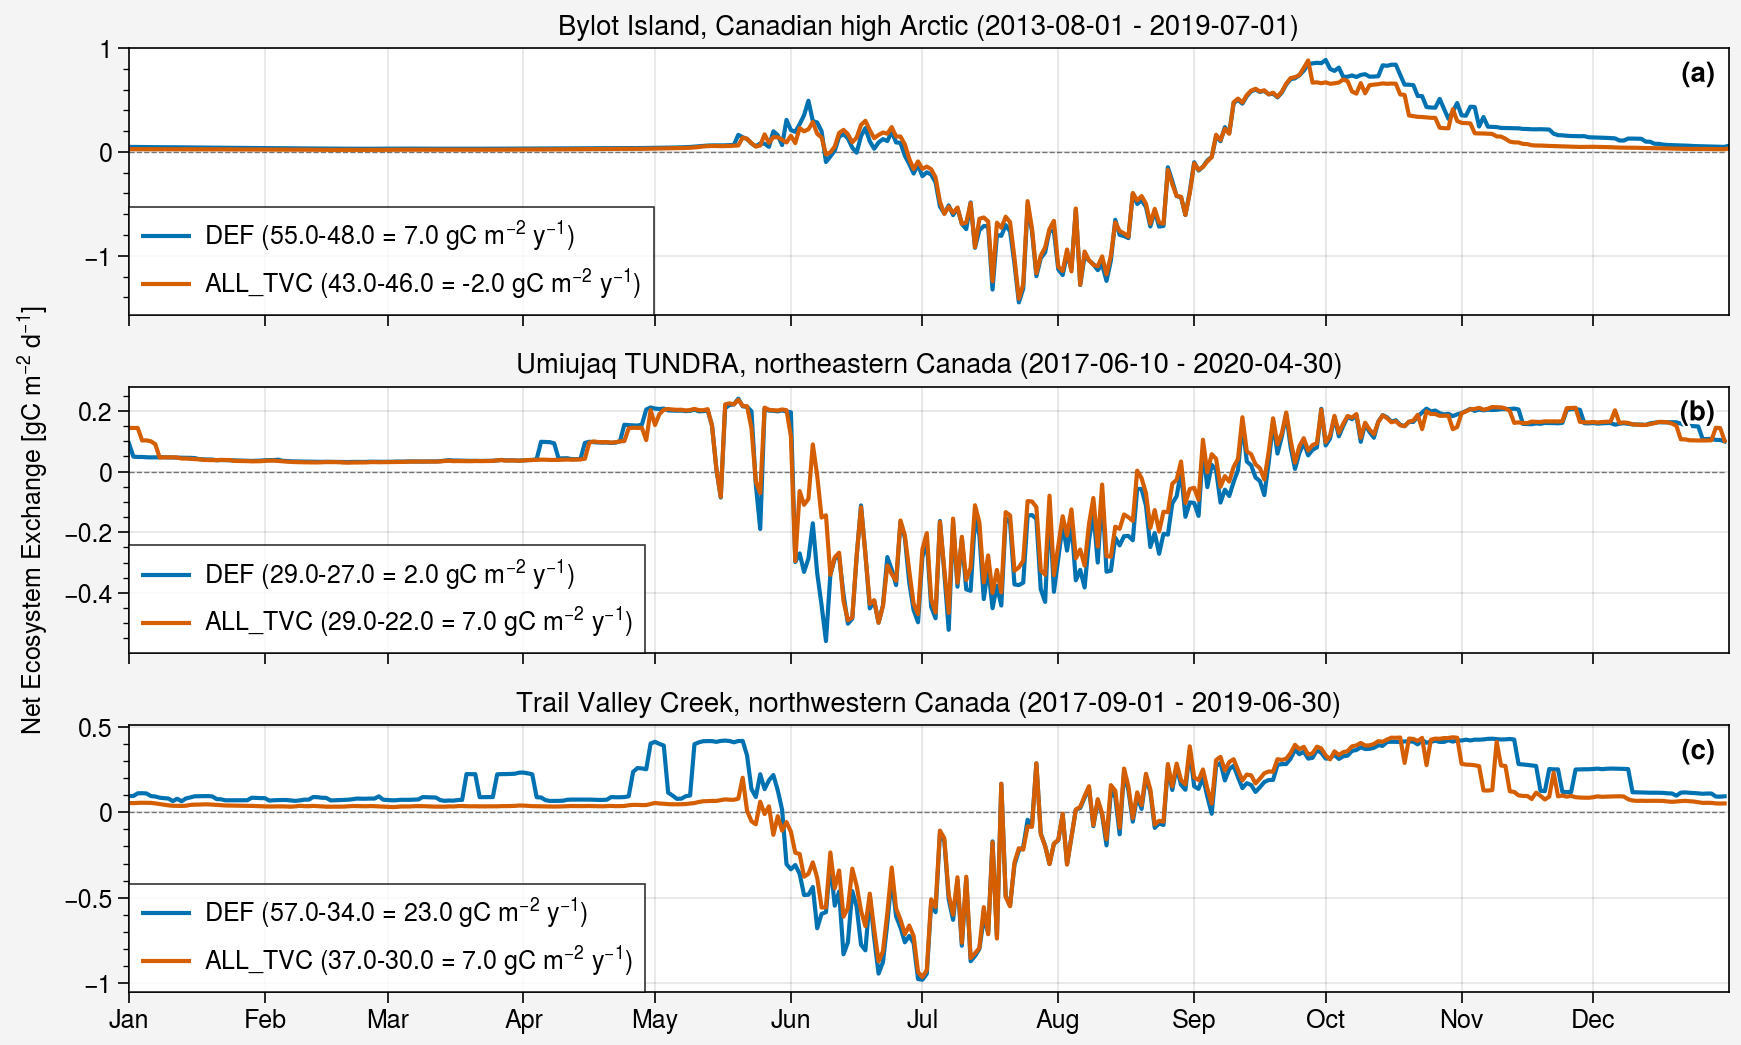

In [ ]:
%matplotlib inline
color_obs = 'gray8'

fig, axs = pplt.subplots(ncols=1, nrows=3, refaspect=6, refwidth=8)

# Month start DOY (non-leap year)
xticks = [
    1,    # Jan
    32,   # Feb
    60,   # Mar
    91,   # Apr
    121,  # May
    152,  # Jun
    182,  # Jul
    213,  # Aug
    244,  # Sep
    274,  # Oct
    305,  # Nov
    335   # Dec
]

# 3-letter month labels
xlabels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


###########
### byl ###
###########

period=slice(str(y_start_byl)+'-08-01',str(y_end_byl)+'-07-01')

# Simus
for ds_d, label, label_exp in zip(ds_d_list_byl, labels, label_exps):
    nep_daily = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3
    
    nep_yearly_budget = nep_daily.sum()
    uptake = nep_daily.where(nep_daily < 0).sum()
    emission = nep_daily.where(nep_daily > 0).sum()
    
    # lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
    lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
    axs[0].plot(nep_daily, label=label_exp + lab_details)
    

axs[0].format(title=site_longname_byl + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [gC m$^{-2}$ d$^{-1}$]')



###########
### umt ###
###########

# period=slice('2015-08',str(y_end_umt)+'-07')
period = slice(str(ds_d_turb.nee.time[0].values)[:-19], str(ds_d_turb.nee.time[-1].values)[:-19])

sdepth = 0.15
sdepth_label = str(int(sdepth*100))
# Simus
for ds_d, label, label_exp in zip(ds_d_list_umt, labels, label_exps):
    nep_daily = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3 #kgC/m2/s -> gC/m2/d
    
    nep_yearly_budget = nep_daily.sum()
    uptake = nep_daily.where(nep_daily < 0).sum()
    emission = nep_daily.where(nep_daily > 0).sum()
    
    # lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
    lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
    axs[1].plot(nep_daily, label=label_exp + lab_details)
    

axs[1].format(title=site_longname_umt + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [gC m$^{-2}$ d$^{-1}$]')


###########
### tvc ###
###########

# period=slice('2017-08',str(y_end_tvc)+'-07')
period = slice(str(ds_d_obs_tvc.NEE_filled.time[0].values)[:-19], str(ds_d_obs_tvc.NEE_filled.time[-1].values)[:-19])

sdepth = 0.05
sdepth_label = str(int(sdepth*100))
# Simus
for ds_d, label, label_exp in zip(ds_d_list_tvc, labels, label_exps):
    nep_daily = -ds_d.nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3
    
    nep_yearly_budget = nep_daily.sum()
    uptake = nep_daily.where(nep_daily < 0).sum()
    emission = nep_daily.where(nep_daily > 0).sum()
    
    # lab_details = ' (Ann bal: '+str(np.round(nep_yearly_budget.values))+')'
    lab_details = ' ('+str(np.round(emission.values))+str(np.round(uptake.values))+' = '+str(np.round(nep_yearly_budget.values))+' gC m$^{-2}$ y$^{-1}$)'
    
    axs[2].plot(nep_daily, label=label_exp + lab_details)

# diff = nep_daily + ds_d_list_tvc[0].nep.sel(time=period).groupby('time.dayofyear').mean()*86400e3
# ax2 = axs[2].twinx()
# ax2.plot(diff, color='orange', linestyle=':', label='ALL_TVC - DEF', alpha=0.8)
# ax2.set_ylabel('Δ NEE [gC m$^{-2}$ d$^{-1}$]', color='orange')
# ax2.tick_params(axis='y', colors='orange')
# ax2.legend(loc='ur', frameon=False)



axs[2].format(title=site_longname_tvc + ' (' + period.start+' - '+period.stop + ')', ylabel='Net Ecosystem Exchange [gC m$^{-2}$ d$^{-1}$]')


for ax in axs:
    # ax.format(ylim=(0,0.9))
    ax.legend(loc='ll', ncols=1)
    ax.hlines(0, 1, 365, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.format(xticks=xticks, xticklabels=xlabels, xtickminor=False, xlabel='')

fig.format(abc='(a)', abcloc='ur')
# fig.suptitle(site_longname_byl)

# fig.save('arctic_nee_correct_SH_no_obs_v3.png')
# fig.save('arctic_nee_correct_SH_no_obs_v3.jpg')
# fig.save('arctic_nee_correct_SH_no_obs_v3.pdf')

In [39]:
ds_d_list_tvc[1]

<xarray.Dataset>
Dimensions:     (time: 2555, layer: 20)
Coordinates:
  * time        (time) datetime64[ns] 2013-01-01 2013-01-02 ... 2019-12-31
  * layer       (layer) float64 0.05 0.15 0.25 0.35 0.45 ... 8.9 18.9 41.4 58.9
Data variables: (12/54)
    longitude   float64 -133.5
    latitude    float64 68.75
    actlyr      (time) float64 0.2817 0.2705 0.2607 0.2525 ... 0.0 0.0 0.0 0.0
    albs        (time) float64 0.7306 0.7567 0.7594 ... 0.7534 0.7922 0.7662
    albsir      (time) float64 0.6335 0.6575 0.6587 ... 0.6452 0.6833 0.652
    albsn       (time) float64 0.8353 0.84 0.8356 ... 0.8109 0.8242 0.7988
    ...          ...
    tsn         (time) float64 -15.62 -12.93 -11.68 ... -25.07 -22.8 -22.21
    tsnbot      (time) float64 -11.81 -9.909 -8.793 ... -21.61 -19.77 -19.23
    vegHeight   (time) float64 0.1531 0.1525 0.1519 ... 0.1516 0.1505 0.1494
    wsnw        (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    wtd         (time) float64 9.999e+03 9.999e+03 ... 9.999e+03 9.999e+03
    zpond       (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    title:        CLASSIC output file
    timestamp:    20250618 1636
    Conventions:  COARDS
    node_offset:  1
    Comment:       run Ref

In [40]:
ds_d.nep.sel(time=slice(ds_d_turb.nee.time[0].values, ds_d_turb.nee.time[-1].values))

<xarray.DataArray 'nep' (time: 935)>
array([ 3.34966745e-09,  3.96060274e-09,  1.67699564e-09,  4.31716124e-09,
        6.46319056e-09,  7.70262536e-09,  9.71628474e-09,  9.21375762e-09,
        8.83239714e-09,  9.75512056e-09,  1.06097445e-08,  8.12463932e-09,
        9.45545393e-09,  7.05906973e-09,  8.91130637e-09,  3.48199676e-09,
        1.60041259e-10,  4.79981796e-10,  7.47867029e-09,  1.05998607e-08,
        1.12972560e-08,  1.06679031e-08,  1.09194588e-08,  4.95345748e-09,
        5.74882134e-09,  6.01105049e-09,  8.27976608e-09,  7.33892585e-09,
        6.98811020e-09,  8.12746751e-09,  1.02186424e-08,  1.05182881e-08,
        1.19570120e-08,  1.14752739e-08,  9.92989852e-09,  3.12344777e-09,
        1.07169368e-08,  1.19126368e-08,  1.03753826e-08,  7.81390027e-09,
        4.40175667e-09, -4.01700431e-10,  5.00345323e-09,  4.39452778e-09,
        4.97890342e-10,  3.15910441e-09,  6.43671458e-09,  7.97086859e-09,
        7.69430089e-09,  6.98658374e-09,  5.56519947e-09,  4.77335883e-09,
        5.06525798e-09,  4.62509512e-09,  3.93075272e-09, -2.86069384e-09,
        5.15867971e-09,  3.70702875e-09,  3.12906242e-09,  1.65991715e-10,
        1.56458243e-09,  1.99149897e-09, -3.39509142e-10,  2.51127895e-09,
       -3.18407586e-09, -4.58976266e-09,  4.49229101e-10,  2.95642204e-09,
        8.95509296e-10,  3.78073244e-10,  2.51511589e-09, -1.08276112e-09,
        1.44913712e-09, -4.91516794e-10,  6.18906336e-10, -1.37777880e-09,
       -1.58240891e-09, -3.69692984e-09, -2.63199428e-09, -1.04691552e-10,
...
       -4.74391314e-09, -4.99168476e-09, -4.73301444e-09, -5.18846593e-09,
       -5.23897376e-09, -1.73043362e-09, -1.43830334e-09, -1.45443411e-09,
       -1.54222399e-09, -1.53995011e-09, -1.54602186e-09, -1.53619597e-09,
       -1.50376105e-09, -1.38708298e-09, -1.38485050e-09, -4.91648452e-09,
       -4.94505263e-09, -1.43856680e-09, -9.55661137e-10, -1.42695823e-09,
       -1.46074253e-09, -1.43055569e-09, -9.61623836e-10, -8.25353878e-10,
       -7.93889288e-10, -7.62489402e-10, -7.32173061e-10, -7.38164892e-10,
       -8.10210011e-10, -5.33498968e-10, -4.13225777e-10, -4.18895813e-10,
       -4.49440018e-10, -4.47193277e-10, -4.20827046e-10, -4.48205115e-10,
       -4.70446377e-10, -5.35585841e-10, -5.83654172e-10, -6.24527127e-10,
       -6.23502103e-10, -6.65801805e-10, -6.59595840e-10, -5.86421045e-10,
       -6.31718533e-10, -7.11402028e-10, -7.15634367e-10, -6.90712870e-10,
       -6.49575923e-10, -6.55215876e-10, -6.33987084e-10, -6.22241963e-10,
       -6.44544664e-10, -6.52781987e-10, -6.32236383e-10, -5.72910551e-10,
       -5.62096765e-10, -5.29088882e-10, -5.06476108e-10, -4.83499157e-10,
       -4.51138716e-10, -4.22408988e-10, -3.92339606e-10, -3.74155479e-10,
       -3.34074746e-10, -2.95998927e-10, -2.79293297e-10, -2.72540902e-10,
       -2.59717496e-10, -2.43967039e-10, -2.20924606e-10, -2.27268553e-10,
       -2.18548885e-10, -2.18175923e-10, -2.10109441e-10, -1.95800976e-10,
       -1.92503909e-10, -2.09399853e-10, -2.19396835e-10])
Coordinates:
  * time     (time) datetime64[ns] 2017-06-10 2017-06-11 ... 2019-12-31
Attributes:
    long_name:   Natural flux of CO2 (expressed as a mass flux of carbon) fro...
    units:       kg m$^{-2}$ s$^{-1}$
    nameInCode:  nep_d_g

In [41]:
str(ds_d_turb.nee.time[0].values)[:-19]

'2017-06-10'

In [42]:
ds_d_turb.nee.time

<xarray.DataArray 'time' (time: 1056)>
array(['2017-06-10T00:00:00.000000000', '2017-06-11T00:00:00.000000000',
       '2017-06-12T00:00:00.000000000', ..., '2020-04-28T00:00:00.000000000',
       '2020-04-29T00:00:00.000000000', '2020-04-30T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2017-06-10 2017-06-11 ... 2020-04-30